# Q2 OOS visual story: does geometry generalize to fresh controllers?

This notebook is a narrative view over the closed, forensic-clean Q2 OOS V2 result. It is not a scientific source of truth: code regenerates figures from hash-validated, release-safe derived tables. Raw generations, benchmark text, and private error arrays are absent from Git. The historical Q2 V4.1 result remains separate.


In [1]:
import math
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
pipeline = __import__(
    'epistemic_geometry.publication.q2_oos.pipeline',
    fromlist=['generate_visual_evidence'],
)
package = pipeline.generate_visual_evidence(ROOT)
TABLE_DIR = ROOT / 'manuscript/data/paper1_q2_oos/derived_figure_tables'
display(Markdown('**Hash validation and deterministic Q2 OOS regeneration: PASS**'))


**Hash validation and deterministic Q2 OOS regeneration: PASS**

## 1. The prospective generalization unit

The 31 historical controllers form a fixed reference atlas. Sixteen new controllers were sampled prospectively, conditioned only on the frozen safety gate, and never redrawn from semantic outcomes. For each fresh controller $i$, the experiment asks whether historical controllers that are geometrically closer also tend to have more similar blind-spot profiles.

The independent unit is **one fresh controller**, not one of the 496 fresh×old dyads.


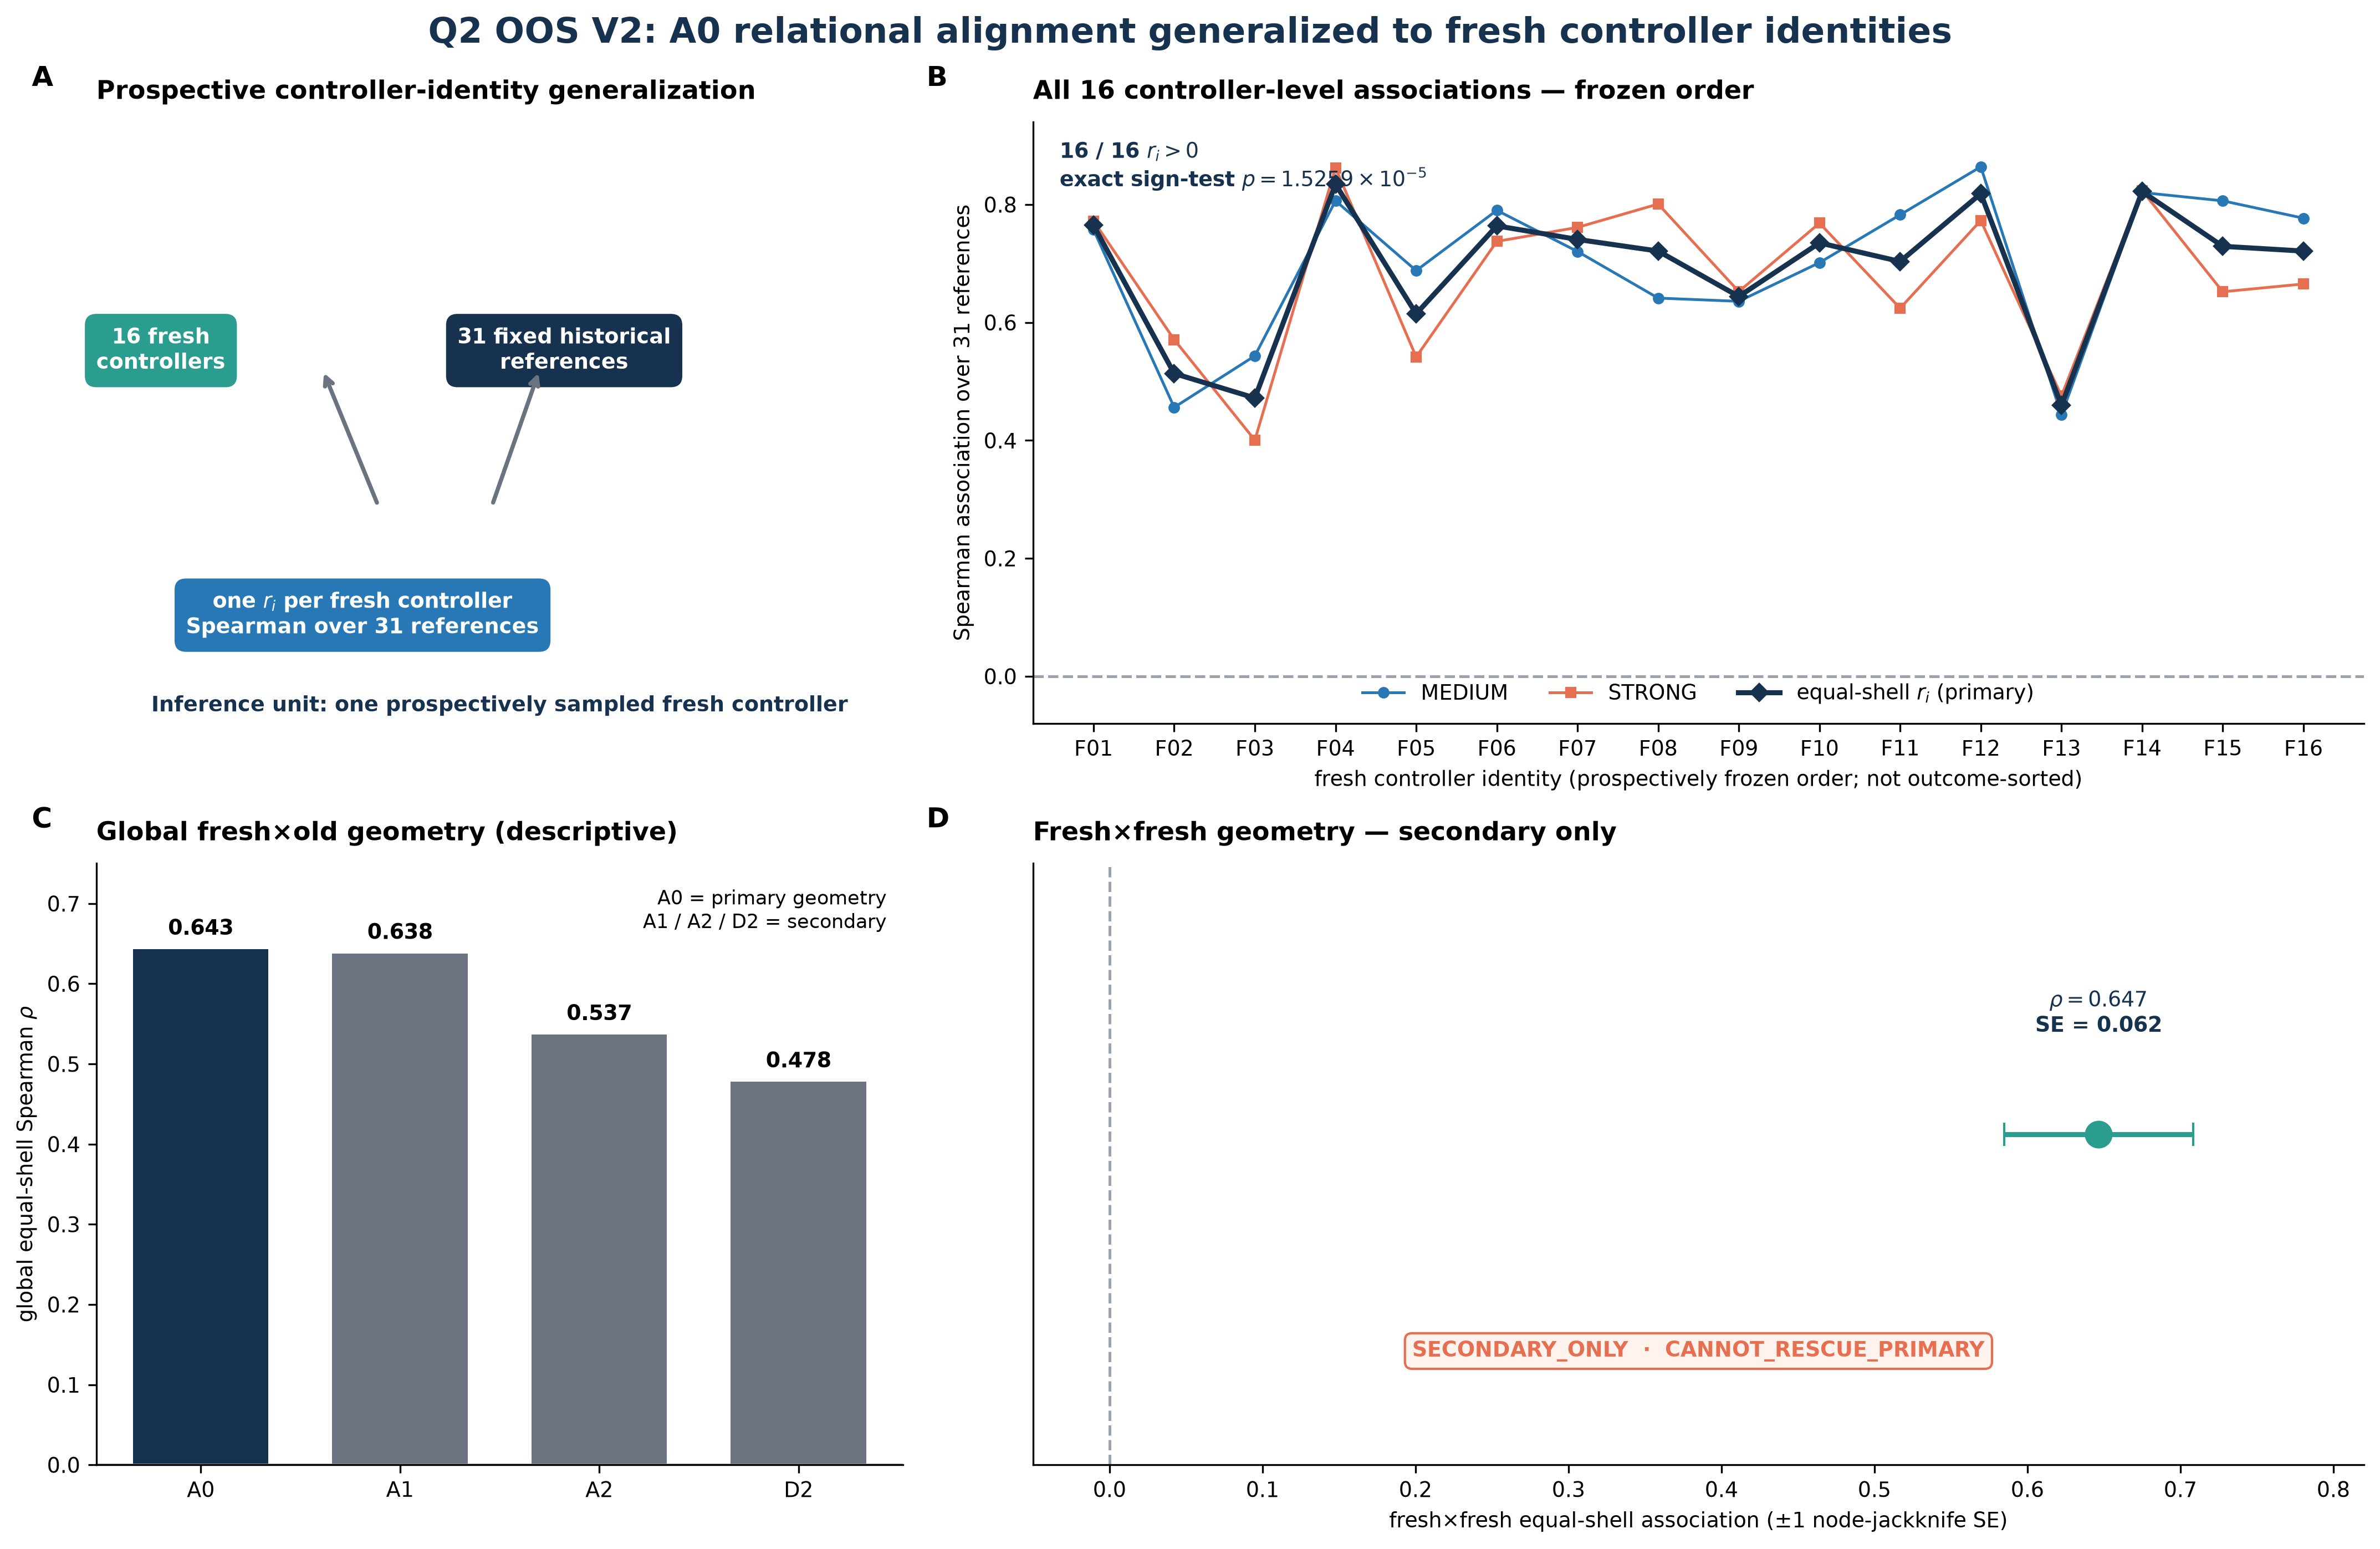

In [2]:
display(Image(filename=str(package['figures']['main']['png'])))


## 2. From intervention distance to blind-spot distance

**A0** is the pre-outcome coefficient-space dissimilarity in the fixed learned rank-8 intervention subspace. It is fixed before semantic outcomes.

For each shell, the two-rollout error profiles give an unbiased finite-panel estimate of centered blind-spot-shape distance $D^{shape}$. Centering removes the component explained only by average error-rate shift. Negative finite-sample estimates are retained.

For fresh controller $i$, correlate $A0(i,j)$ with $D^{shape}(i,j)$ over the 31 historical references $j$, separately in MEDIUM and STRONG shells, then average the two correlations:

$$r_i=\tfrac12[\rho_S(A0_{i,\cdot}^{M},D_{i,\cdot}^{shape,M})+\rho_S(A0_{i,\cdot}^{S},D_{i,\cdot}^{shape,S})].$$


In [3]:
controllers = pd.read_csv(TABLE_DIR / 'controller_associations.csv')
display(controllers)


**Frozen controller table:** 16 of 16 equal-shell associations are positive.

## 3. Exact controller-level sign test

The prospectively frozen null is $P(r_i>0)\leq 0.5$; zero counts as non-success. The exact one-sided Binomial upper tail uses the 16 controller signs. Global correlation is descriptive and cannot replace this controller-level inference.


In [4]:
positive = int(controllers['primary_positive'].sum())
total = len(controllers)
exact_p = sum(math.comb(total, k) for k in range(positive, total + 1)) / 2**total
display(Markdown(
    f'**Primary:** {positive}/{total} positive; exact one-sided $p={exact_p:.12g}$. '
    'Classification: `Q2_OOS_V2_A0_PASS`.'
))


**Primary:** 16/16 positive; exact one-sided $p=1.52587890625e-05$. Classification: `Q2_OOS_V2_A0_PASS`.

## 4. Global geometry and secondary analyses

The full 16×31 association is a useful effect-size summary but its dyads are dependent. A1, A2, and D2 were frozen secondary geometries. The fresh×fresh result uses a node-level jackknife and is `SECONDARY_ONLY_CANNOT_RESCUE_PRIMARY`.


**Primary and secondary roles are encoded in the committed tables and figure spec.**

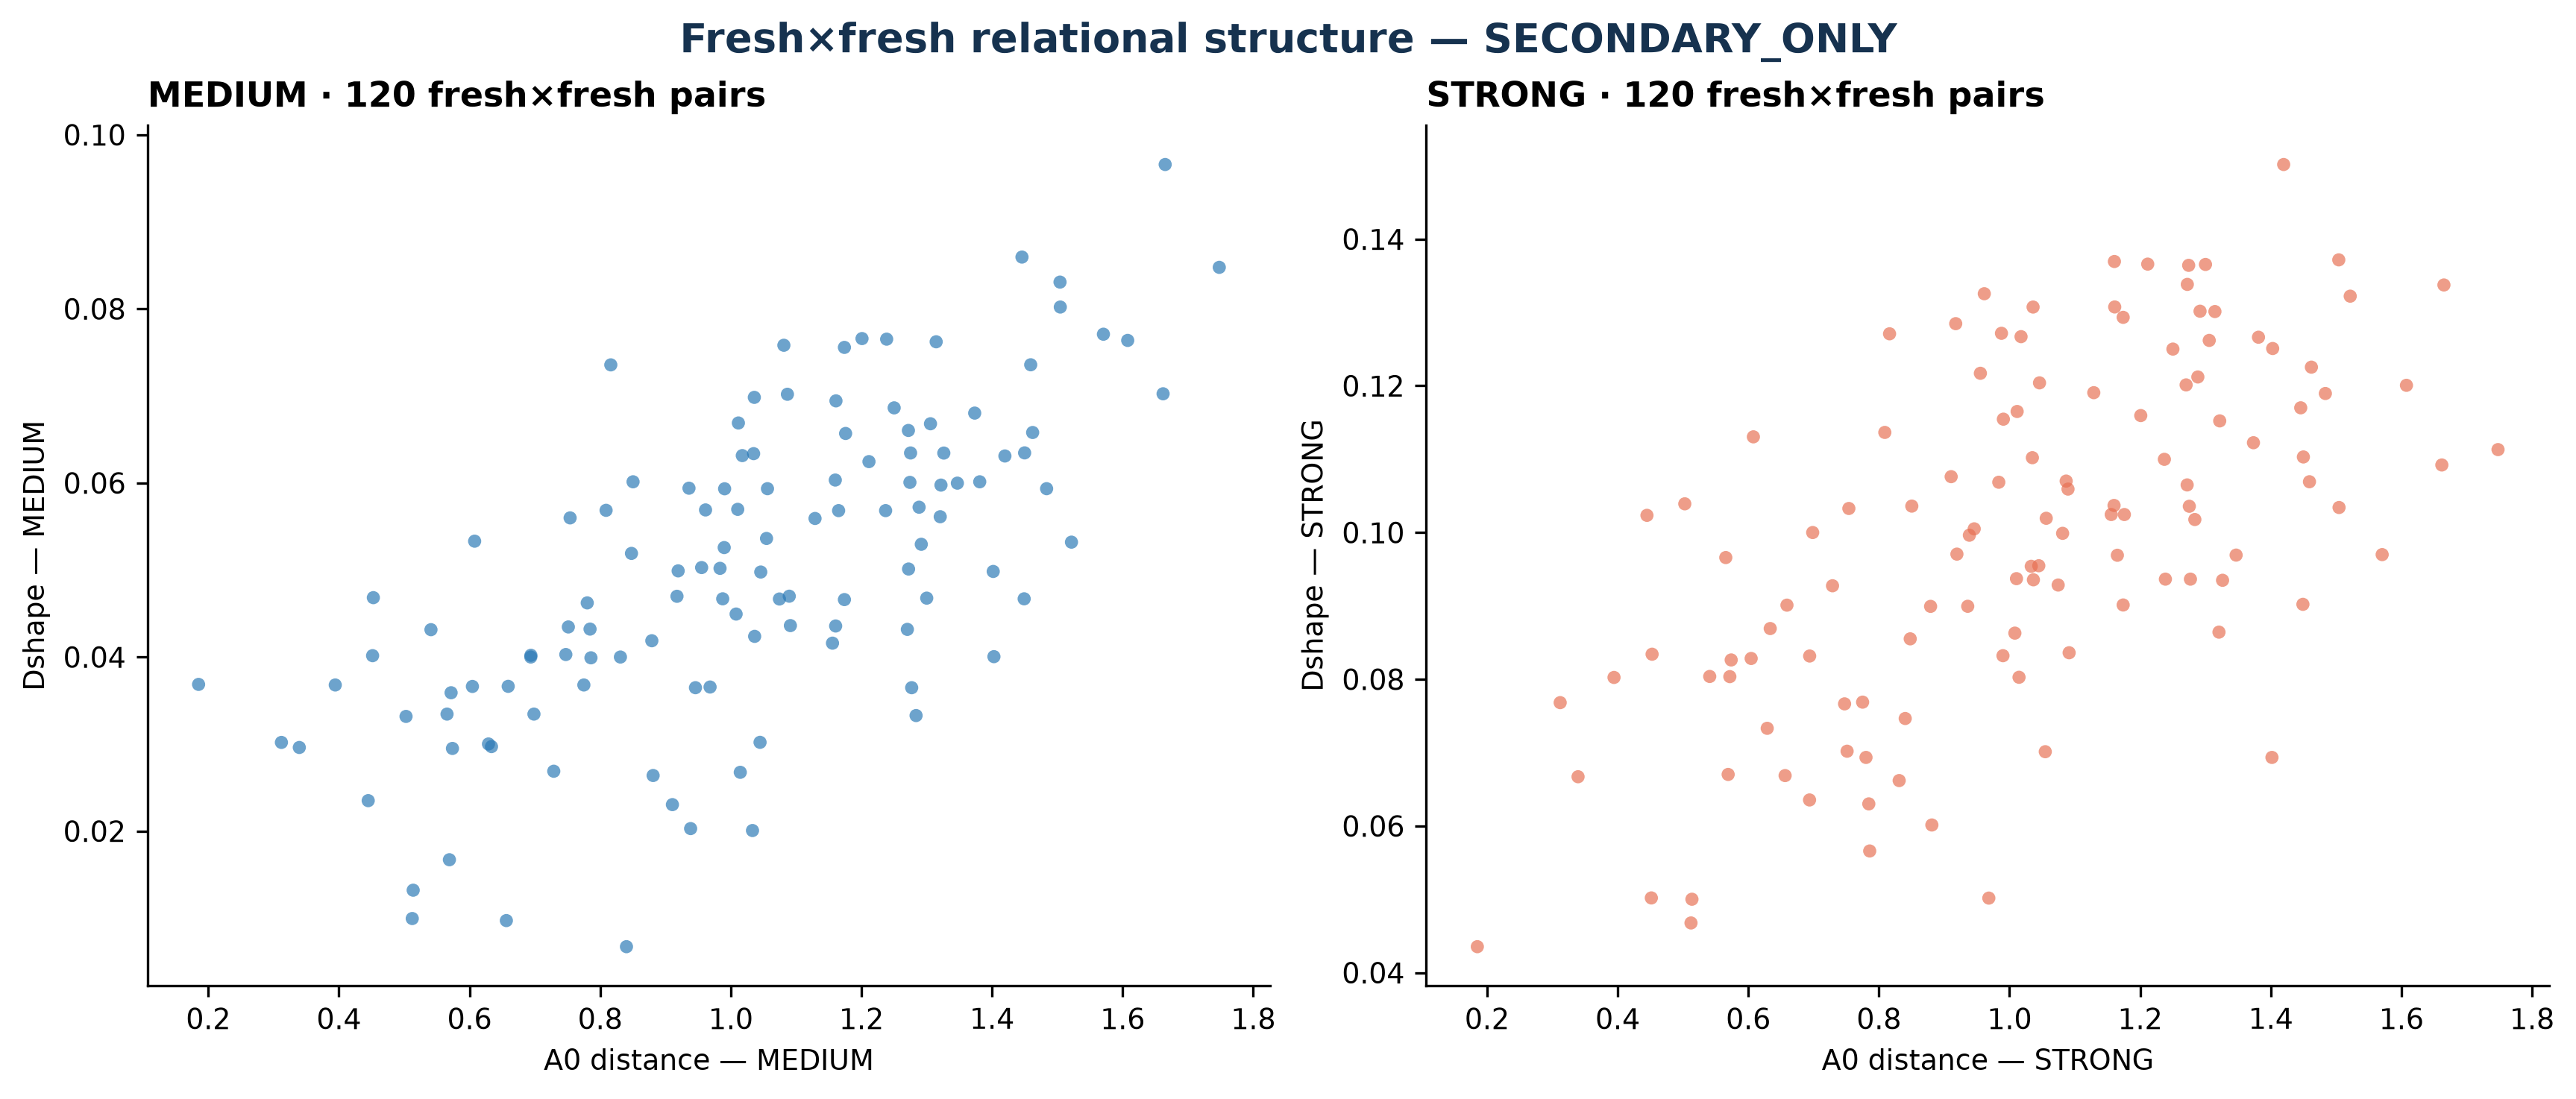

In [5]:
globals_ = pd.read_csv(TABLE_DIR / 'global_associations.csv')
fresh_fresh = pd.read_csv(TABLE_DIR / 'fresh_fresh_summary.csv')
display(globals_)
display(fresh_fresh)
display(Image(filename=str(package['figures']['s3']['png'])))


## 5. Robustness across shells and controller identities

The shell plot exposes the two components of every $r_i$ without sorting by outcome. The LOFO plot removes each fresh controller in the same frozen order; it is a sensitivity analysis, not a second primary test.


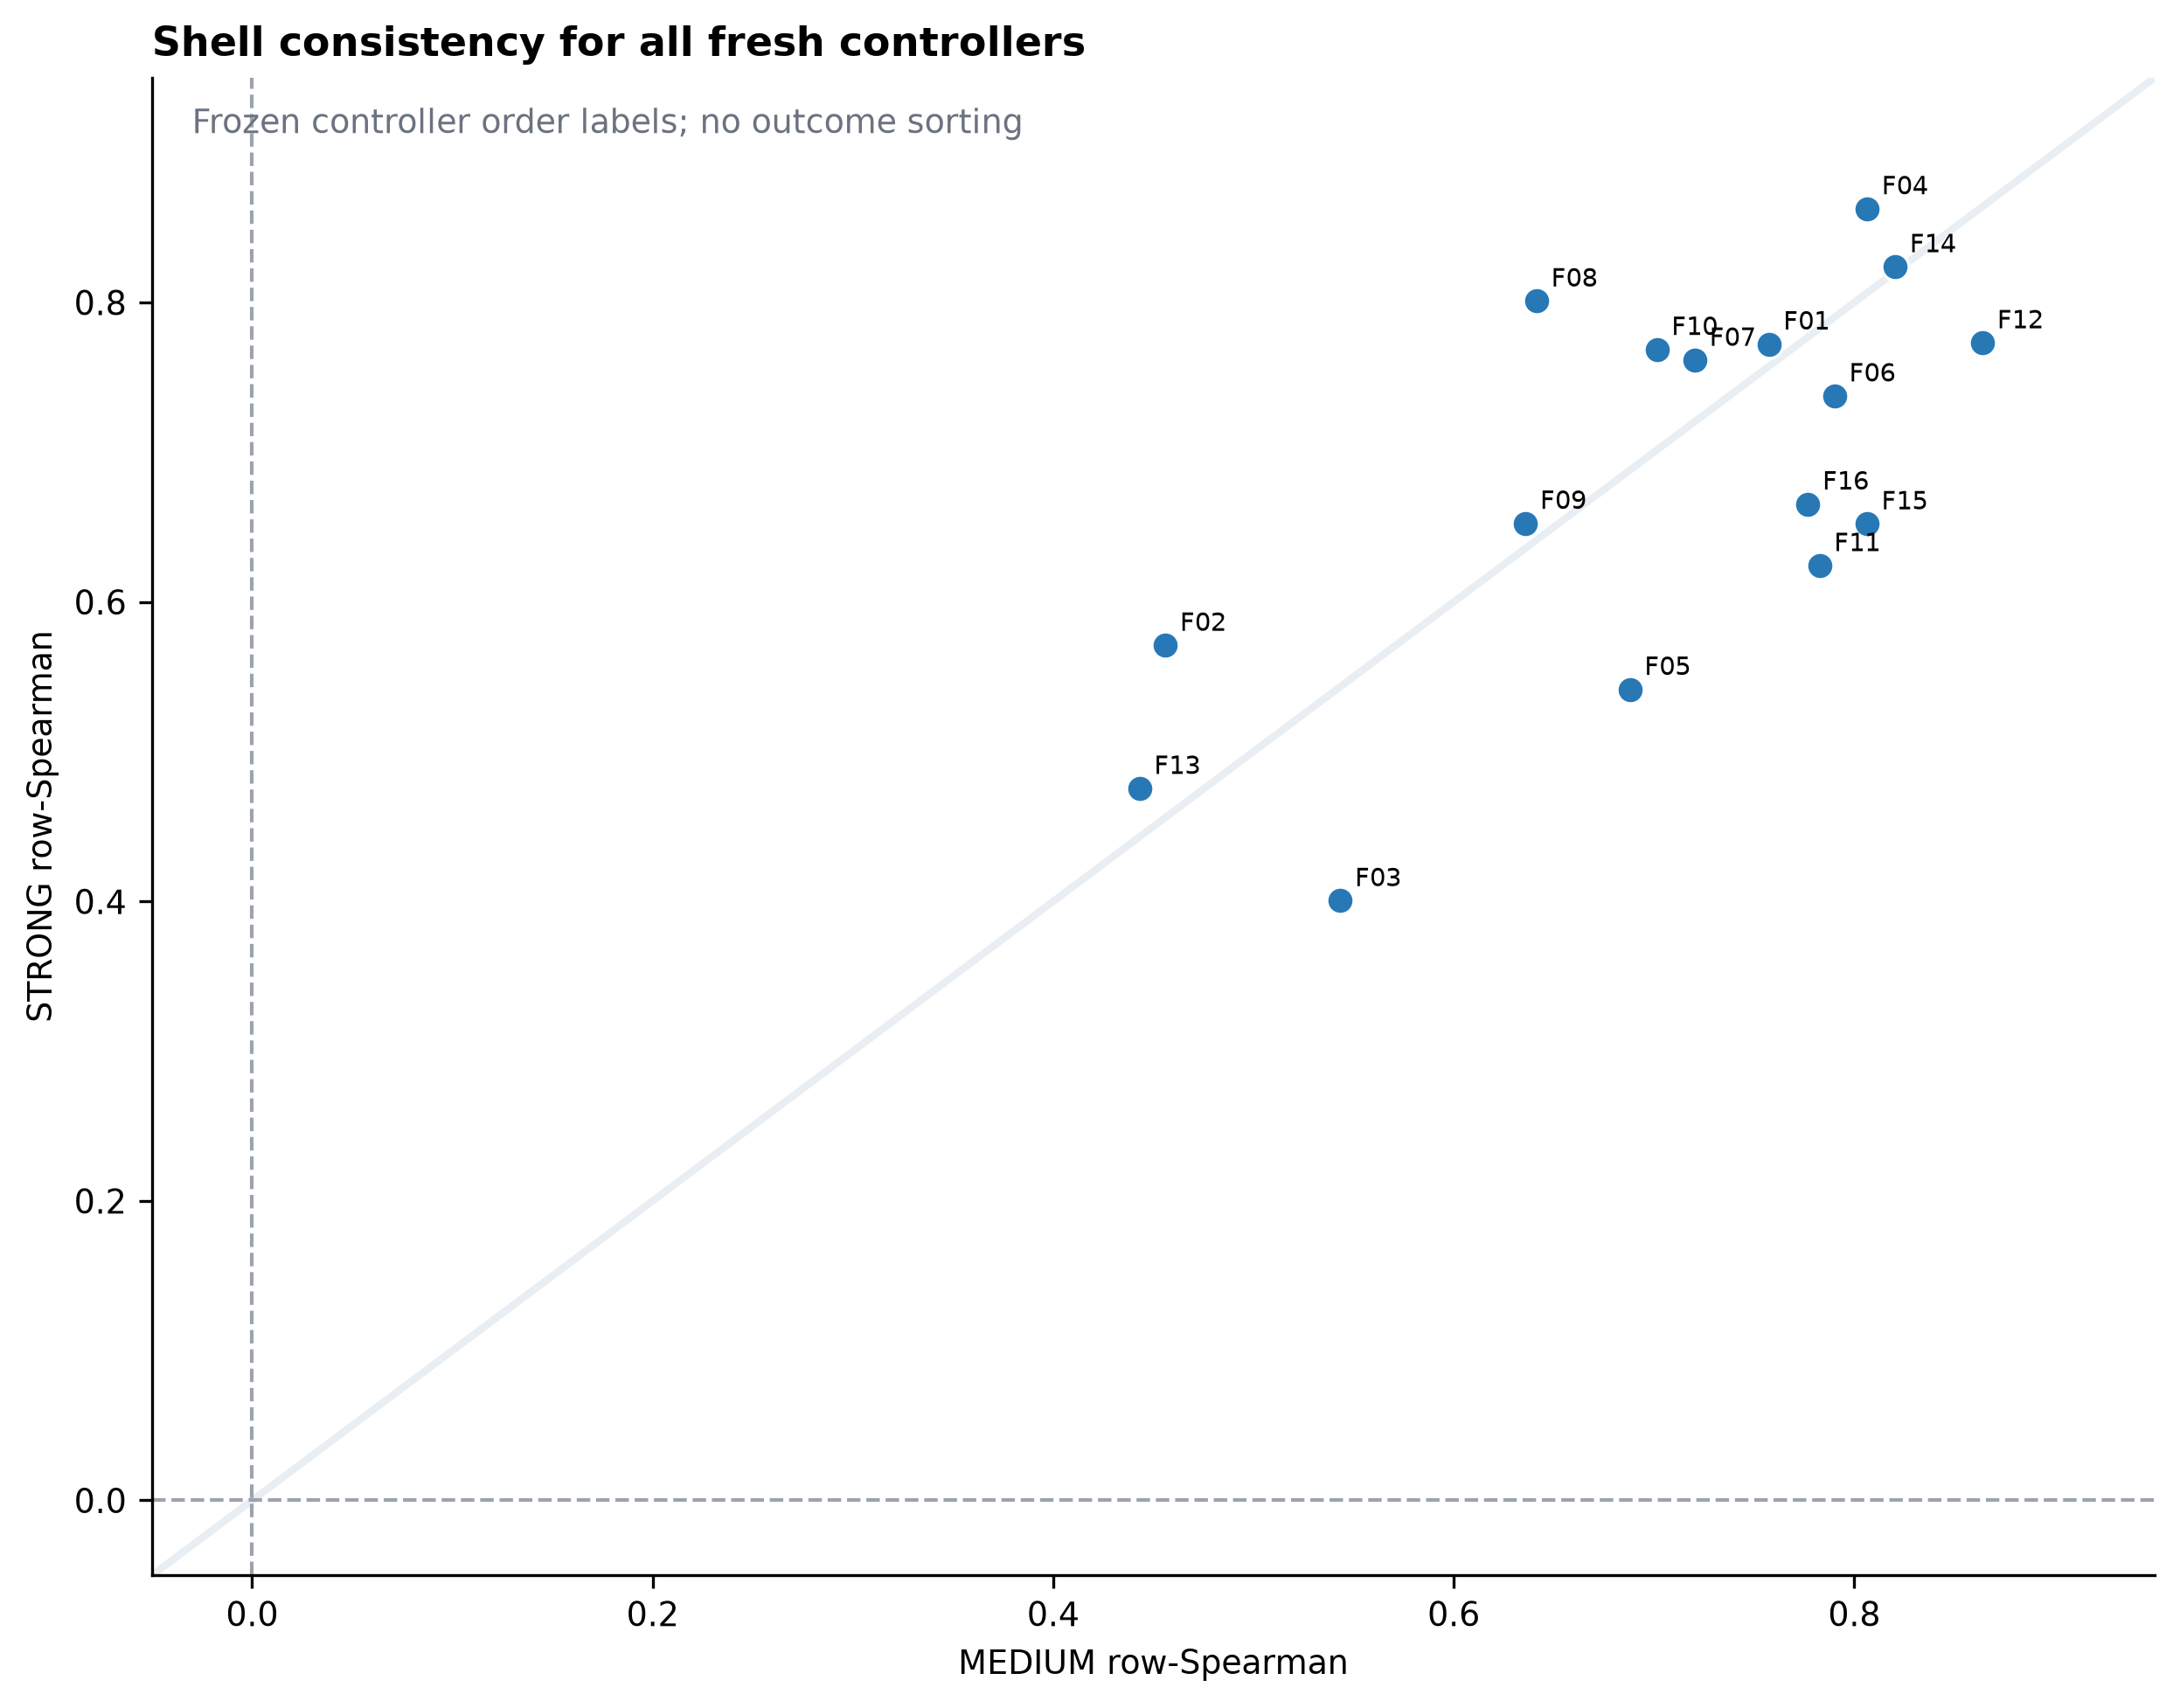

In [6]:
display(Image(filename=str(package['figures']['s1']['png'])))


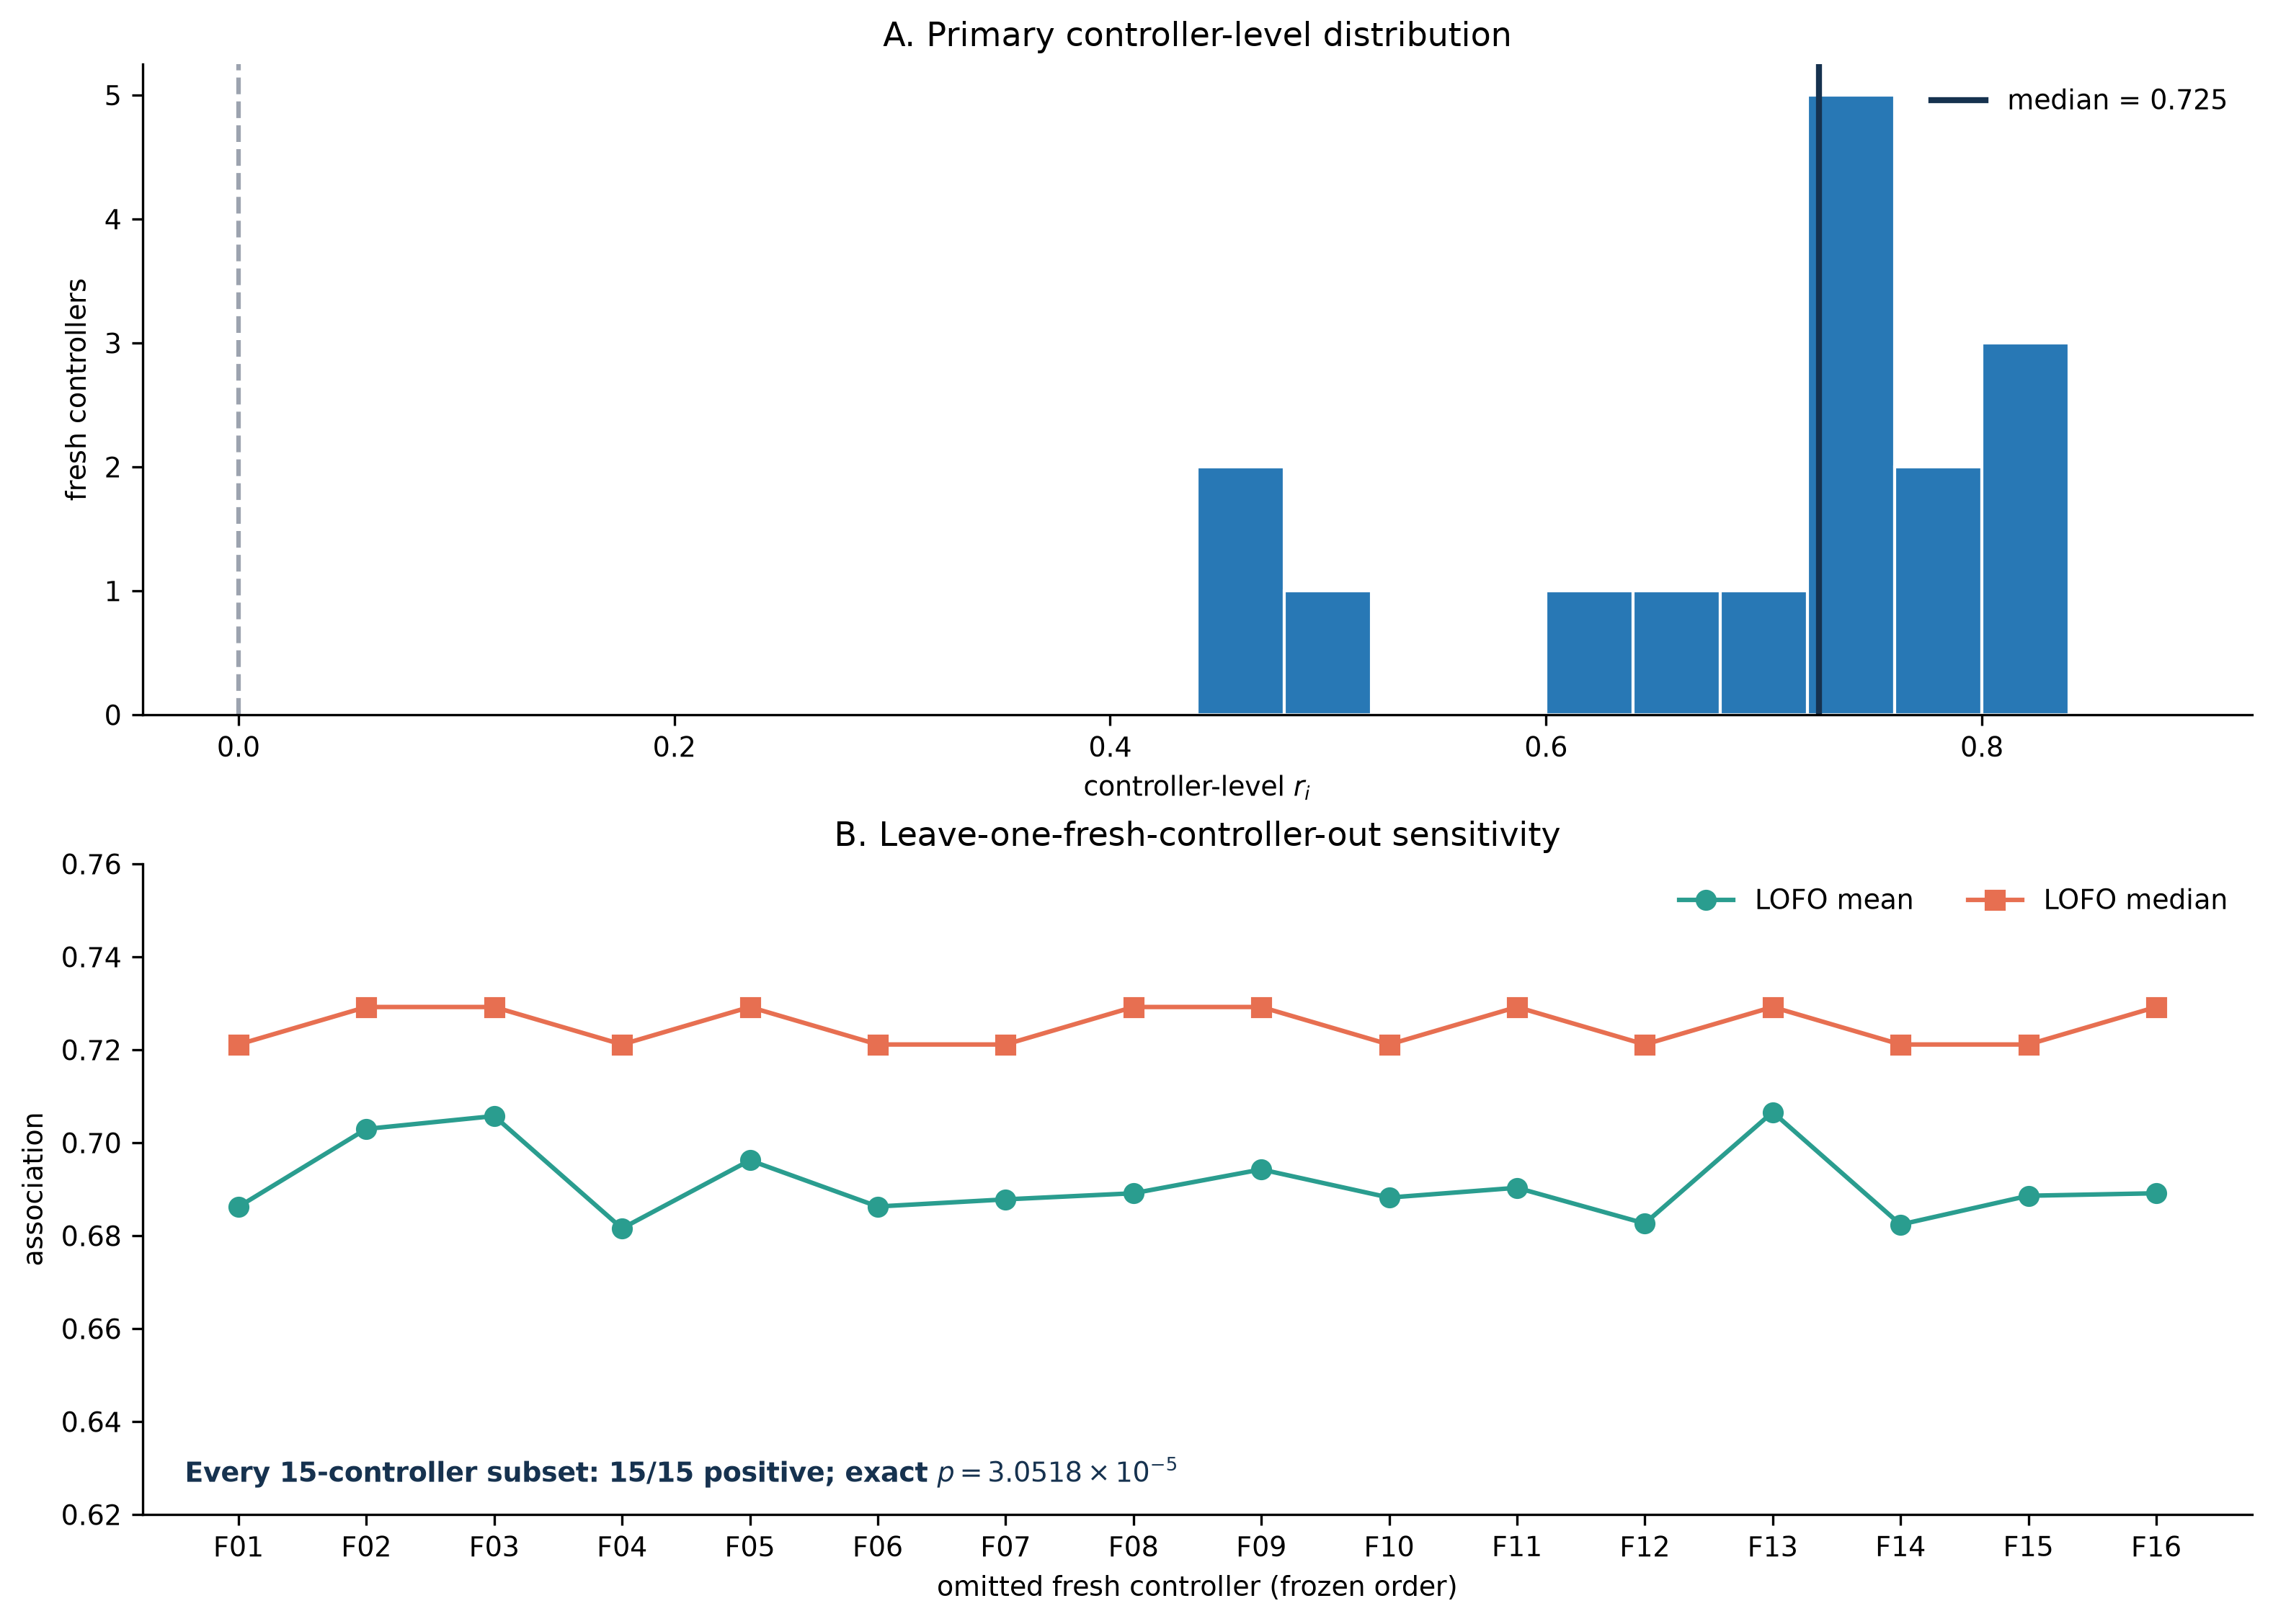

In [7]:
display(Image(filename=str(package['figures']['s2']['png'])))


## 6. Why the archived item bootstrap is not shown as a confidence interval

A post-closeout audit reproduced the historical 50,000 item resamples exactly and found no defect in the primary objects. An ordinary size-300 resample contains only about 190 unique items and about 150 multiplicity-effective items. Recomputing the nonlinear two-rollout $D^{shape}$→Spearman estimator on that perturbed support shifts the distribution downward. Synthetic calibration did not validate conventional percentile-CI coverage.

The archived values are therefore displayed only as an **item-panel perturbation sensitivity distribution**. No post-hoc replacement interval strengthens the primary result.


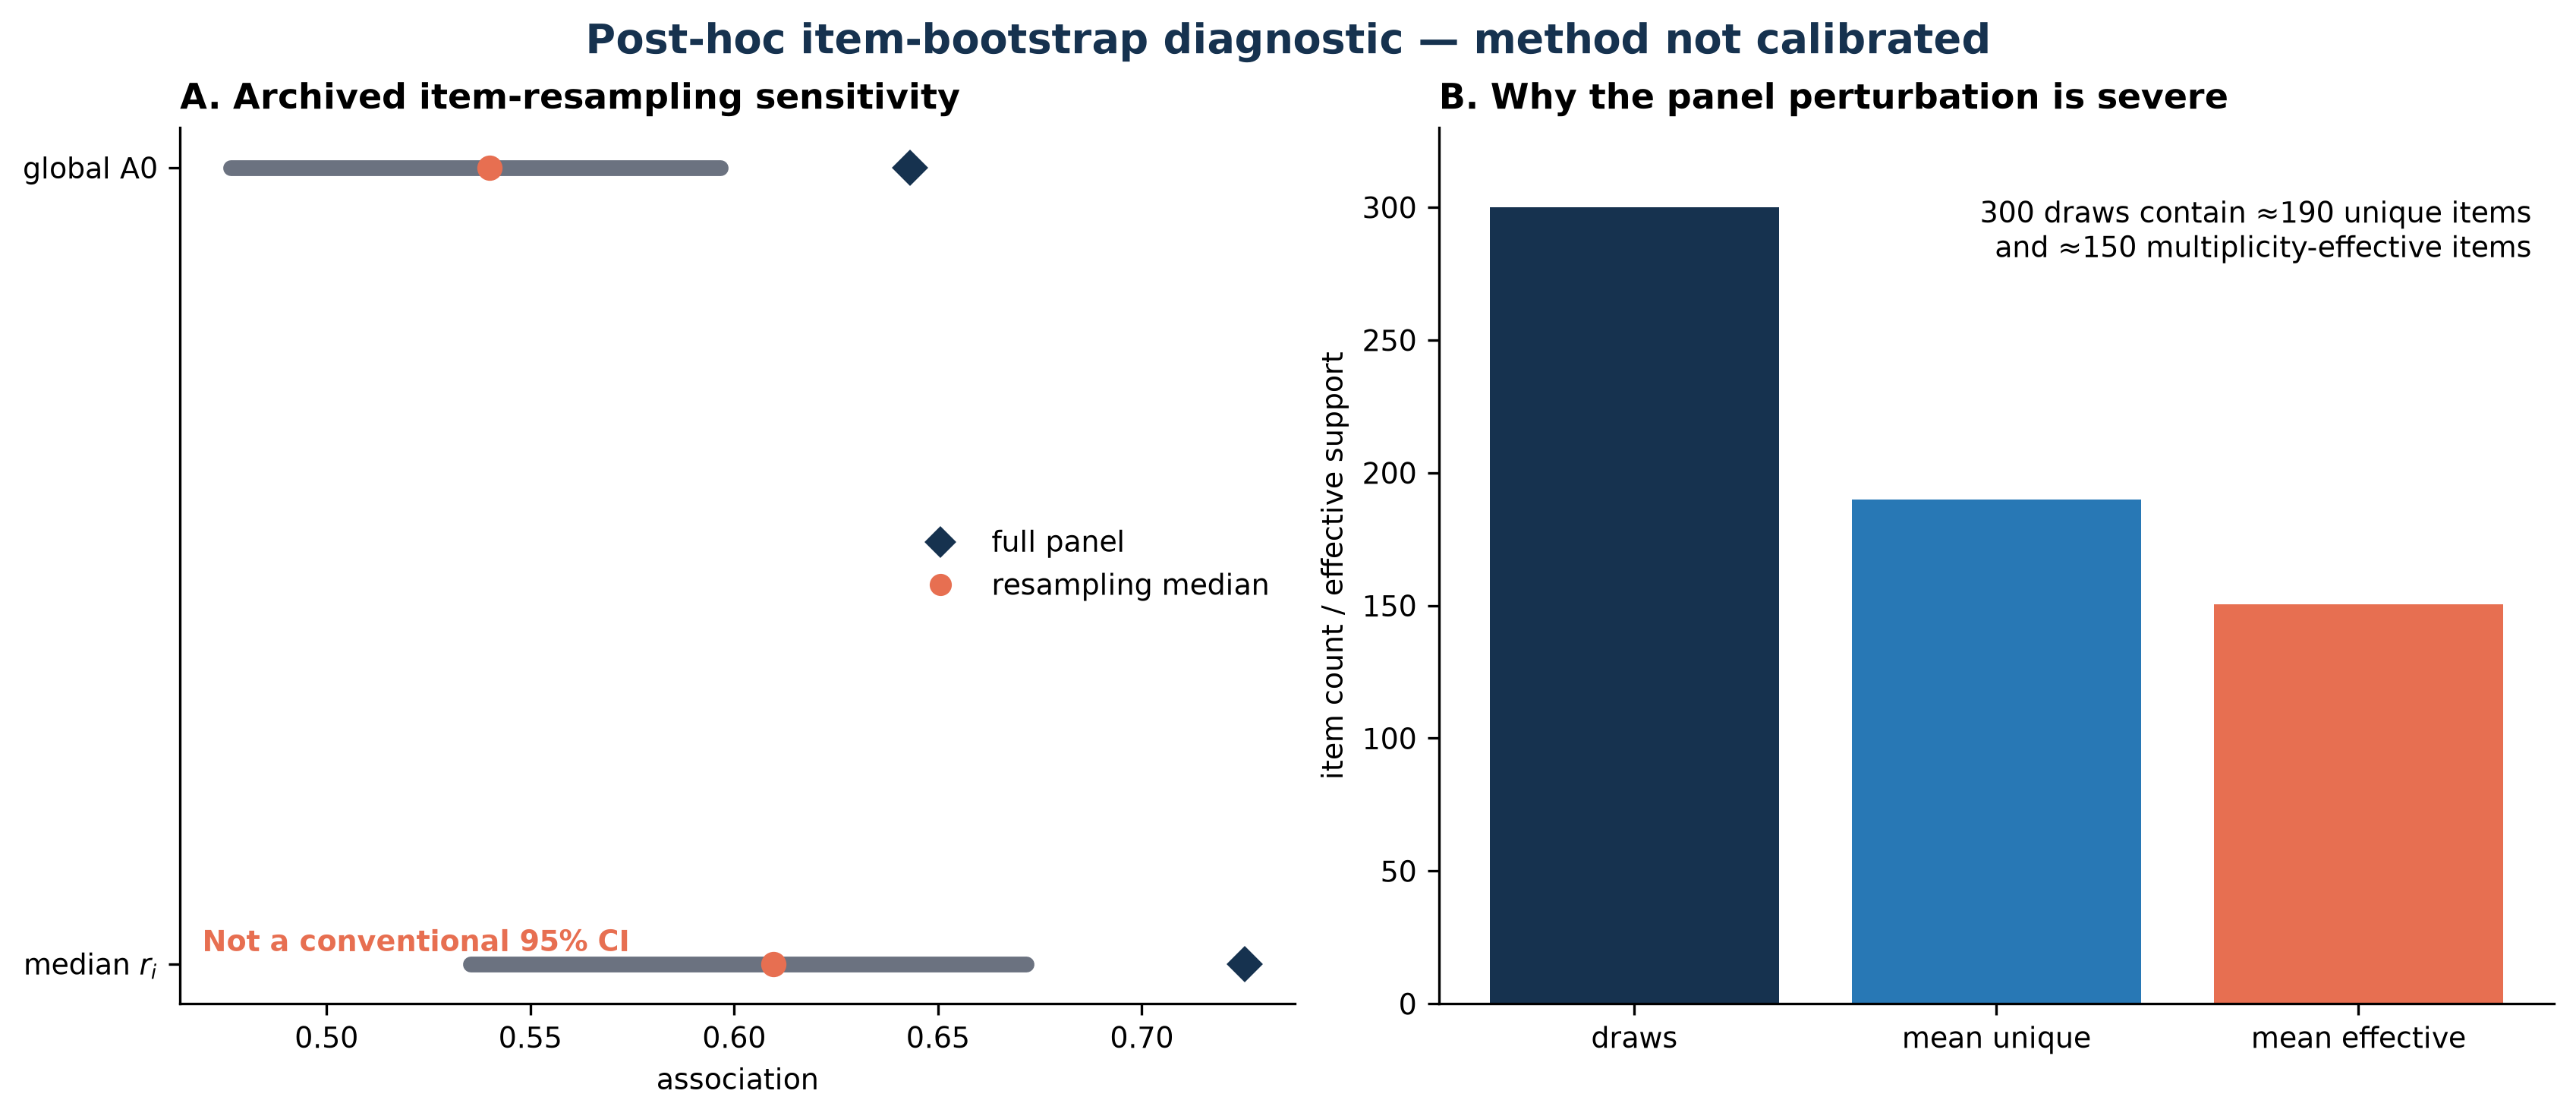

In [8]:
display(Image(filename=str(package['figures']['s5']['png'])))


## 7. Claim boundary

The result supports controller-identity generalization **within** the same frozen Qwen3-8B, CRUXEval, layer-27, learned rank-8 intervention laboratory and fixed 31-controller atlas. It does not establish cross-task or cross-model generalization, random-subspace specificity, universal geometry, manifold structure, or Q3 utility. A matched random rank-8 subspace control remains a prospective design question.

To regenerate the public package from committed tables, run `python scripts/generate_q2_oos_paper_figures.py`. Regenerating the derived tables requires the private hash-pinned `D_SHAPE.npz`; the public manifest records its identity.
